In [31]:
# Only run this cell if the required packages are not installed
!pip install pandas matplotlib scikit-learn numpy

Defaulting to user installation because normal site-packages is not writeable


In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [33]:
filesDir = "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/"
models = ["19to1", "19to7to1", "19to2to1"]
samples = ["bkg", "Ato4l", "LQ", "hToTauTau", "hToTauNu"]
quantizations = ["float32", "16bit"]

In [34]:
model_colors = {
    "19to1" : "#d62728", # red
    "19to7to1" : "#2ca02c", # green
    "19to2to1" : "#1f77b4", # blue
}
quant_linestyles = {
    "float32": "-", # dashed
    "16bit": "--" # dot dashed
}


In [35]:
sample_colors = {
    "bkg": "#1f77b4", # blue
    "Ato4l": "#ff7f0e", # orange
    "hToTauTau": "#2ca02c", # green
    "hToTauNu": "#d62728", # red
    "LQ": "#9467bd", # purple
}

In [36]:
legend_names = {
    "float32": "float32",
    "32bit": "32-bit",
    "28bit": "28-bit",
    "24bit": "24-bit",
    "20bit": "20-bit",
    "18bit": "18-bit",
    "16bit": "16-bit",
    "14bit": "14-bit",
    "13bit": "13-bit",
    "12bit": "12-bit",
    "8bit": "8-bit",
    "bkg": "Background",
    "Ato4l": "$A\u21924l$",
    "hToTauTau": "$h^0\u2192\u03C4\u03C4$",
    "hToTauNu": "$h^\u00b1\u2192\u03C4\u03BD$",
    "LQ": "$LQ\u2192b\u03C4$",
    "19to1" : "19\u21921",
    "19to7to1" : "19\u21927\u21921",
    "19to2to1" : "19\u21922\u21921",
}

In [37]:
# Where to save the comparison plots
output_plot_dir = "../output/ModelComparison/"
os.makedirs(output_plot_dir, exist_ok=True)

In [38]:
def load_norm_data(file_path):
    """Load normalization data from a whitespace-delimited file."""
    # Only keep the first column (norm values) and ignore the rest
    return pd.read_csv(file_path, sep='\s+', comment="#", header=None, usecols=[0], names=['norm'])

In [39]:
norms = {}

for model in models:
    norms[model] = {}

    for quant in quantizations:
        bit_dir = filesDir + "/" + model + "/" + quant
        norms[model][quant] = {}

        for sample in samples:
            file_path = os.path.join(bit_dir, sample + ".dat")
            df = load_norm_data(file_path)
            norms[model][quant][sample] = df['norm'].to_numpy()


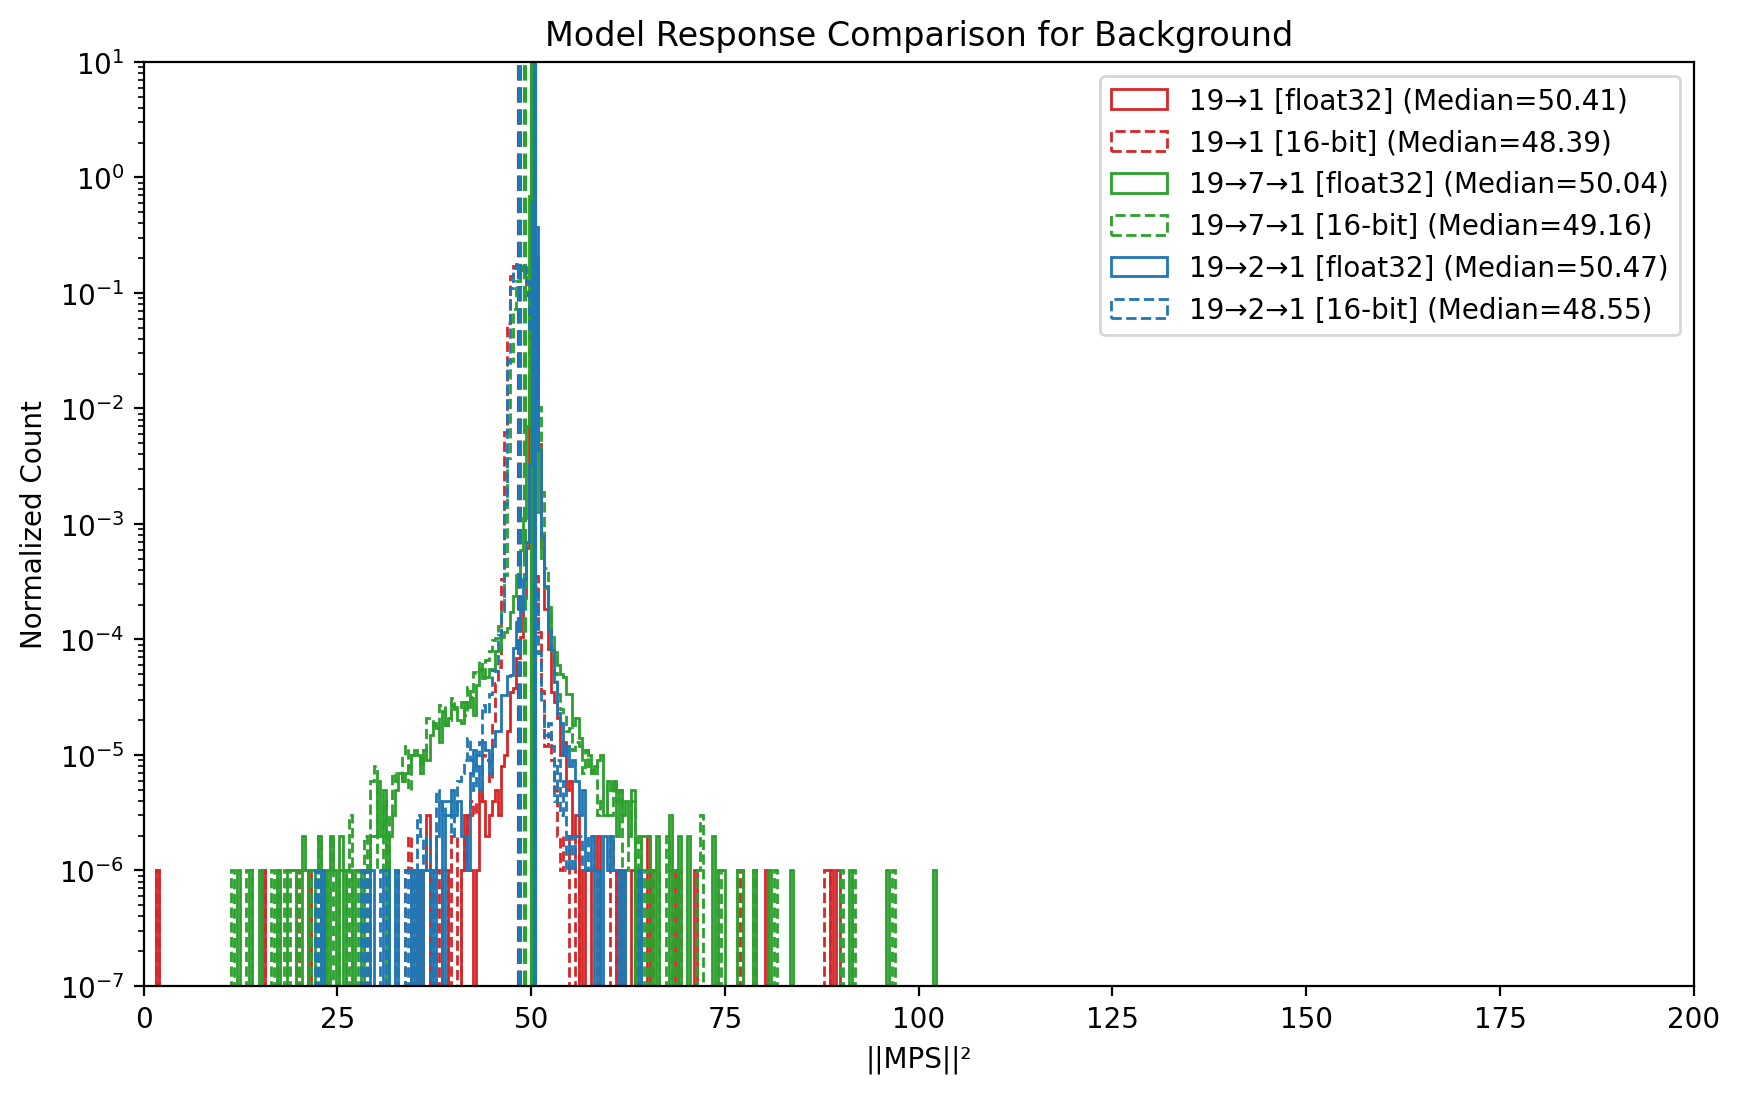

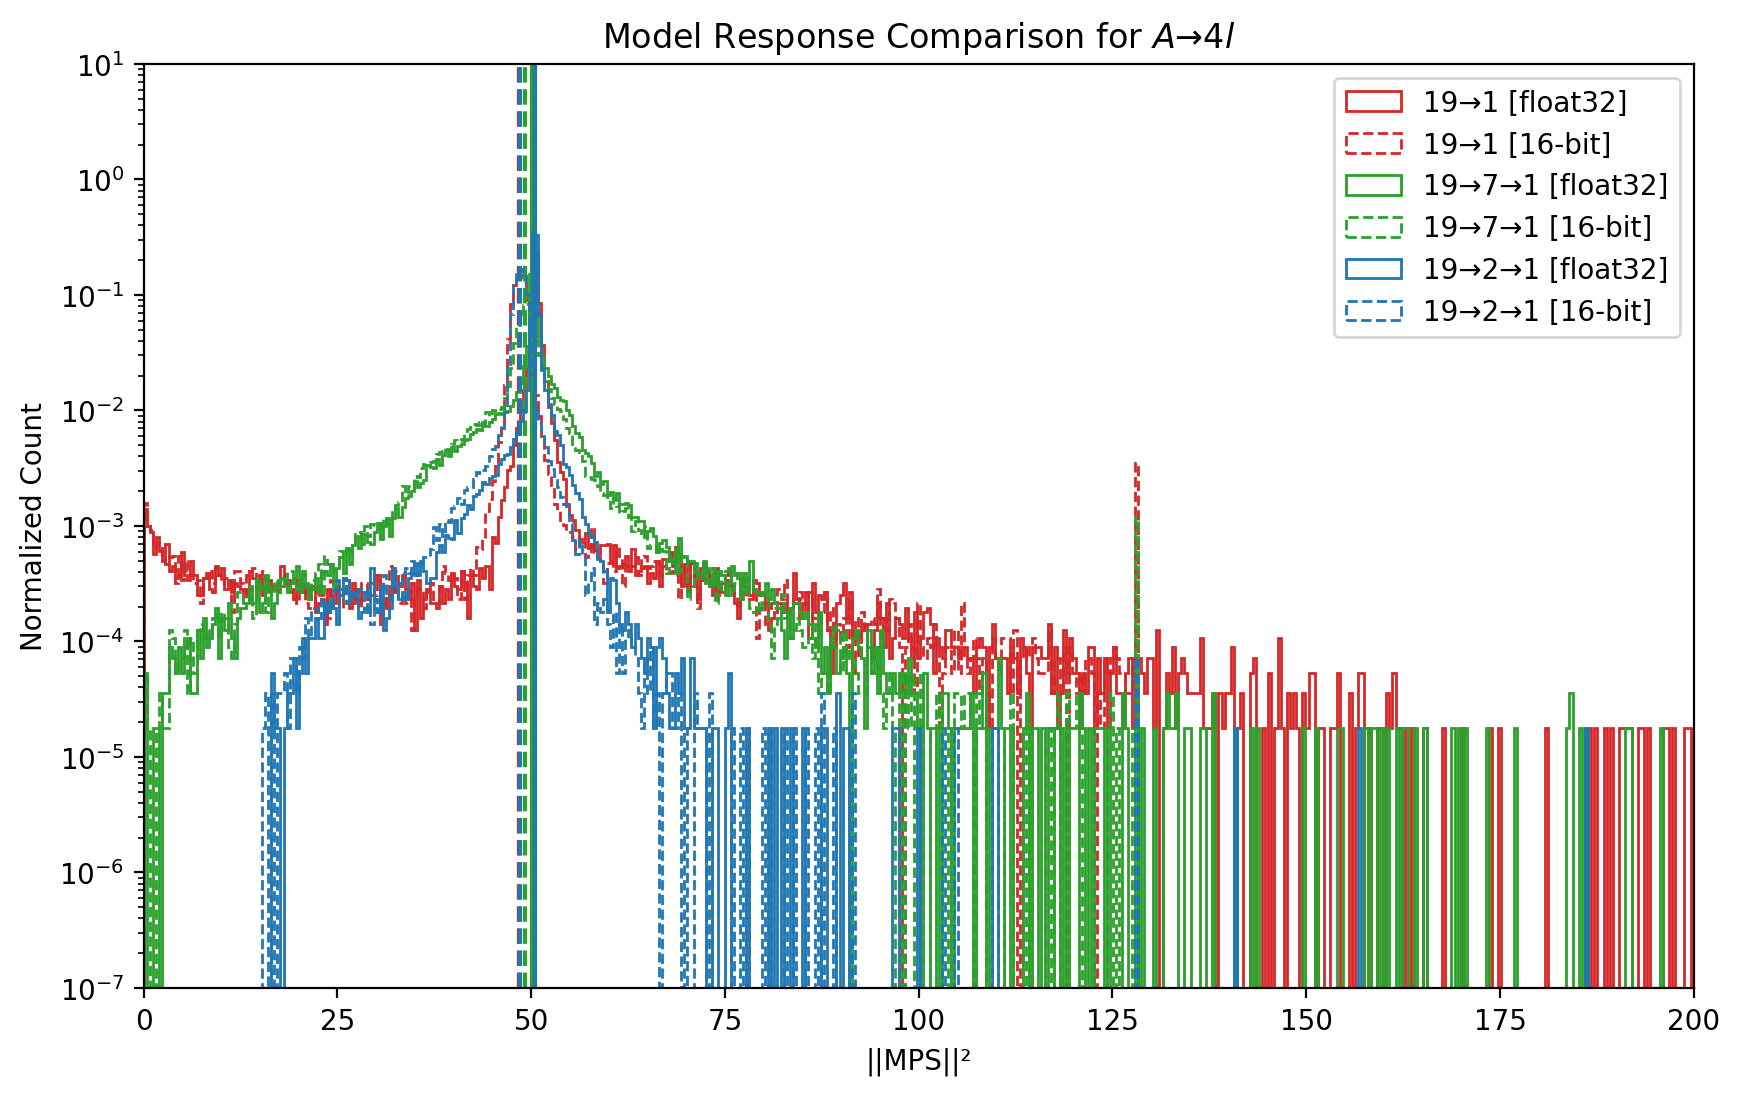

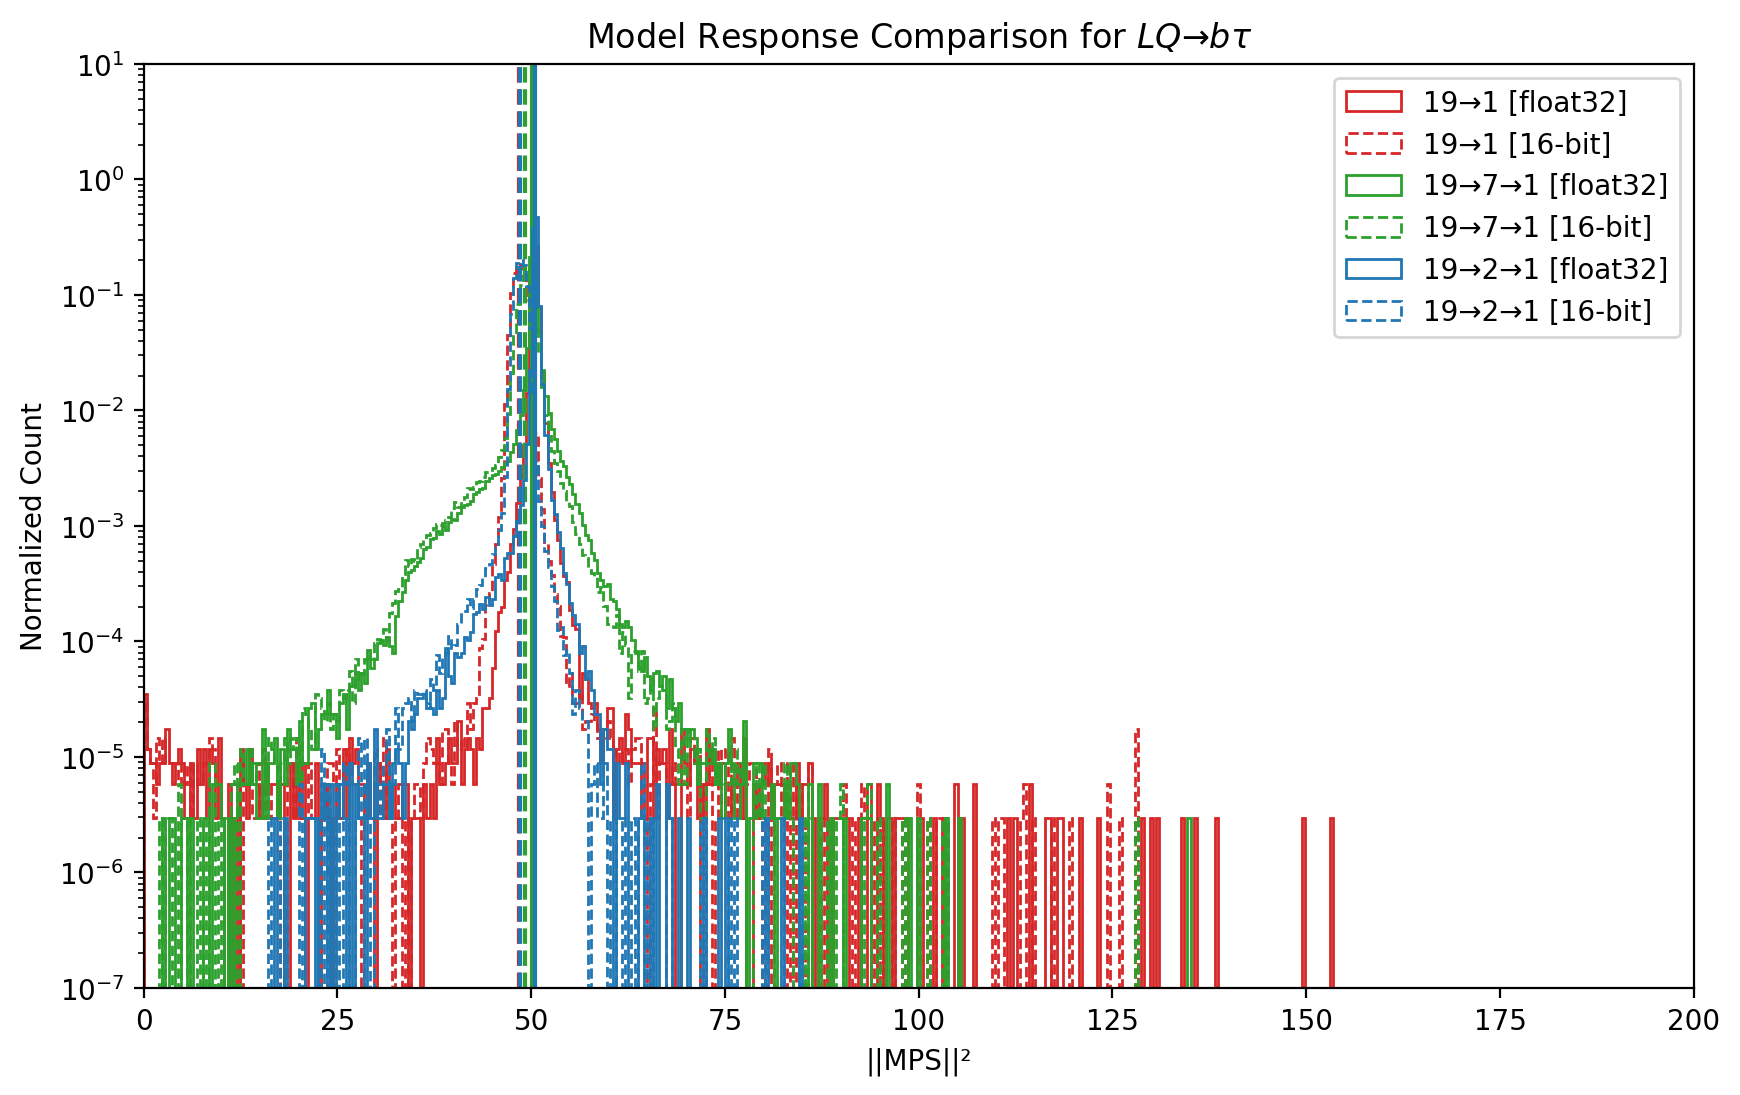

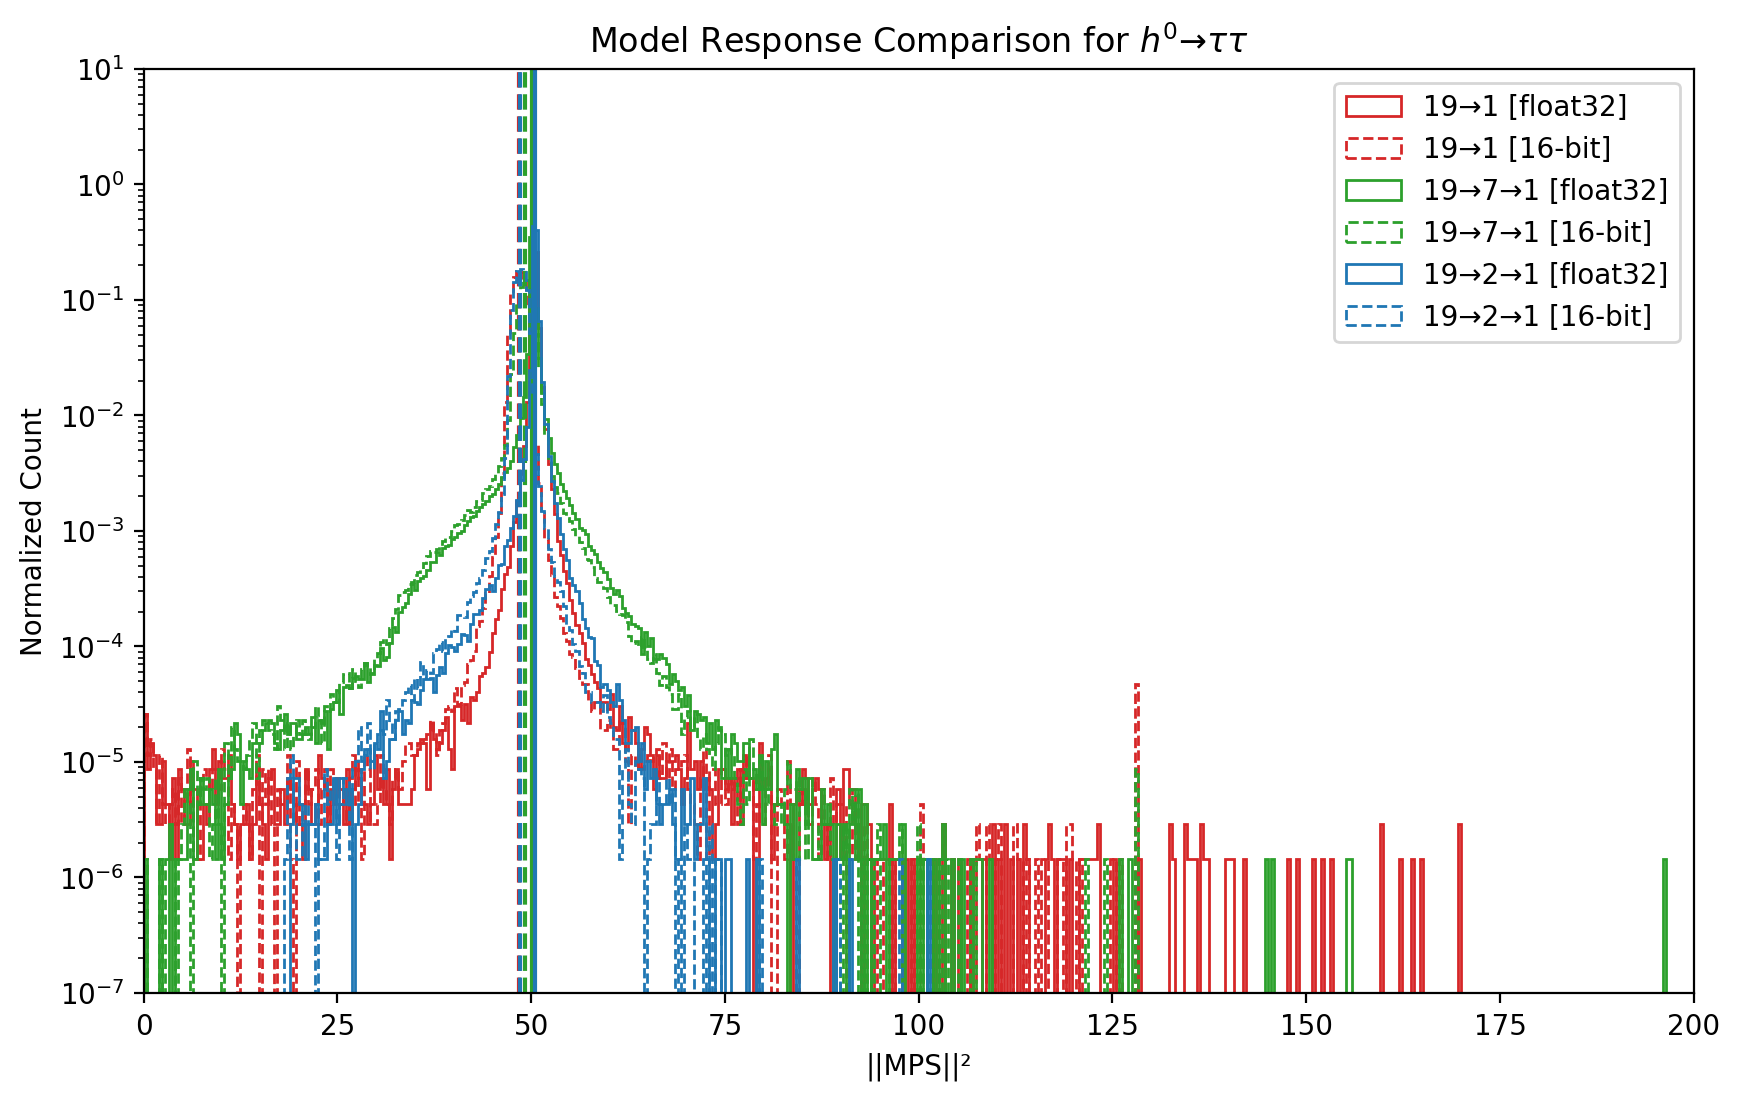

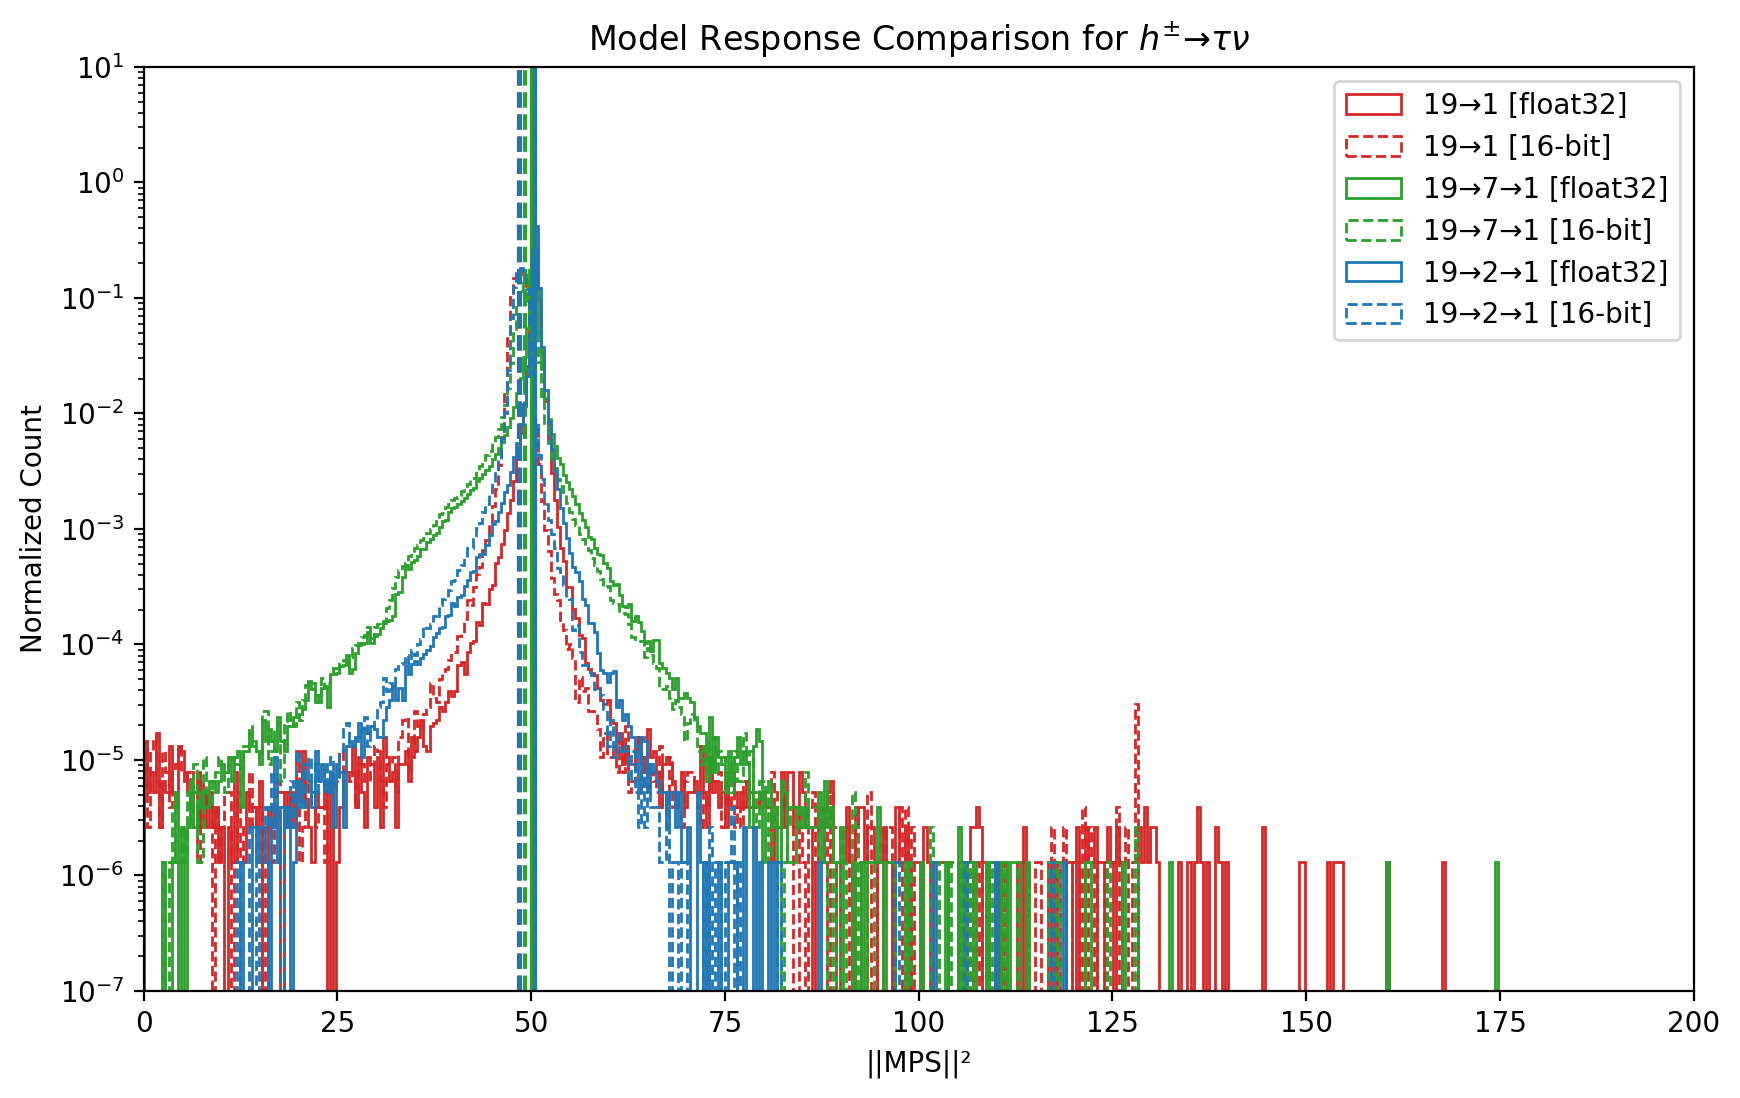

In [40]:
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, 500)
median = {}
for model in models:
    median[model] = {}
    for quant in quantizations:
        median[model][quant] = np.median(norms[model][quant]["bkg"])
for sample in samples:
    plt.figure(figsize=(10, 6), dpi=200)
    for model in models:
        for quant in quantizations:
            label = f"{legend_names[model]} [{legend_names[quant]}]"
            if sample == "bkg":
                label += f" (Median={median[model][quant]:.2f})"
            plt.hist(norms[model][quant][sample], weights=np.array([1.]*len(norms[model][quant][sample]))/len(norms[model][quant][sample]), bins=bins, histtype='step', color=model_colors[model], linestyle=quant_linestyles[quant], label=label)
            plt.axvline(median[model][quant], color=model_colors[model], linestyle=quant_linestyles[quant])
    plt.xlabel("||MPS||\u00b2")
    plt.yscale("log")
    plt.ylim(1e-7, 10)
    plt.xlim(xmin, xmax)
    plt.ylabel("Normalized Count")
    plt.title(f"Model Response Comparison for {legend_names[sample]}")
    plt.legend()
    plt.show()

In [41]:
def get_anomaly_scores(norm, target):
    return np.abs(norm - target)

In [42]:
anomaly_scores = {}
for model in models:
    anomaly_scores[model] = {}
    for quant in quantizations:
        anomaly_scores[model][quant] = {}
        for sample in samples:
            anomaly_scores[model][quant][sample] = get_anomaly_scores(norms[model][quant][sample], median[model][quant])

In [43]:
#copying same roc def as tn4ml eval 
def get_roc_curve_data(y_true: np.ndarray, y_scores: np.ndarray, anomaly_det: bool = False):
    if anomaly_det:
        true_val = np.concatenate((np.ones(y_scores.shape[0]), np.zeros(y_true.shape[0])))
        pred_val = np.concatenate((y_scores, y_true))
    else:
        true_val = y_true
        pred_val = y_scores
    
    fpr, tpr, _ = roc_curve(true_val, pred_val, drop_intermediate=False)

    return fpr, tpr

In [44]:
roc_data = {}
roc_data["tpr"] = {}
roc_data["fpr"] = {}
roc_data["auc"] = {}
roc_data["tpr_at_1e_5_fpr"] = {}
for model in models:
    roc_data["tpr"][model] = {}
    roc_data["fpr"][model] = {}
    roc_data["auc"][model] = {}
    roc_data["tpr_at_1e_5_fpr"][model] = {}
    for quant in quantizations:
        roc_data["tpr"][model][quant] = {}
        roc_data["fpr"][model][quant] = {}
        roc_data["auc"][model][quant] = {}
        roc_data["tpr_at_1e_5_fpr"][model][quant] = {}
        for sample in samples:
            if sample == "bkg":
                continue
            roc_data["fpr"][model][quant][sample], roc_data["tpr"][model][quant][sample] = get_roc_curve_data(anomaly_scores[model][quant]["bkg"], anomaly_scores[model][quant][sample], anomaly_det=True)
            roc_data["auc"][model][quant][sample] = auc(roc_data["fpr"][model][quant][sample], roc_data["tpr"][model][quant][sample])
            idx_1e_5 = np.searchsorted(roc_data["fpr"][model][quant][sample], 1e-5, side='right') - 1
            roc_data["tpr_at_1e_5_fpr"][model][quant][sample] = roc_data["tpr"][model][quant][sample][idx_1e_5] if idx_1e_5 >= 0 else 0.0

<Figure size 2000x1200 with 0 Axes>

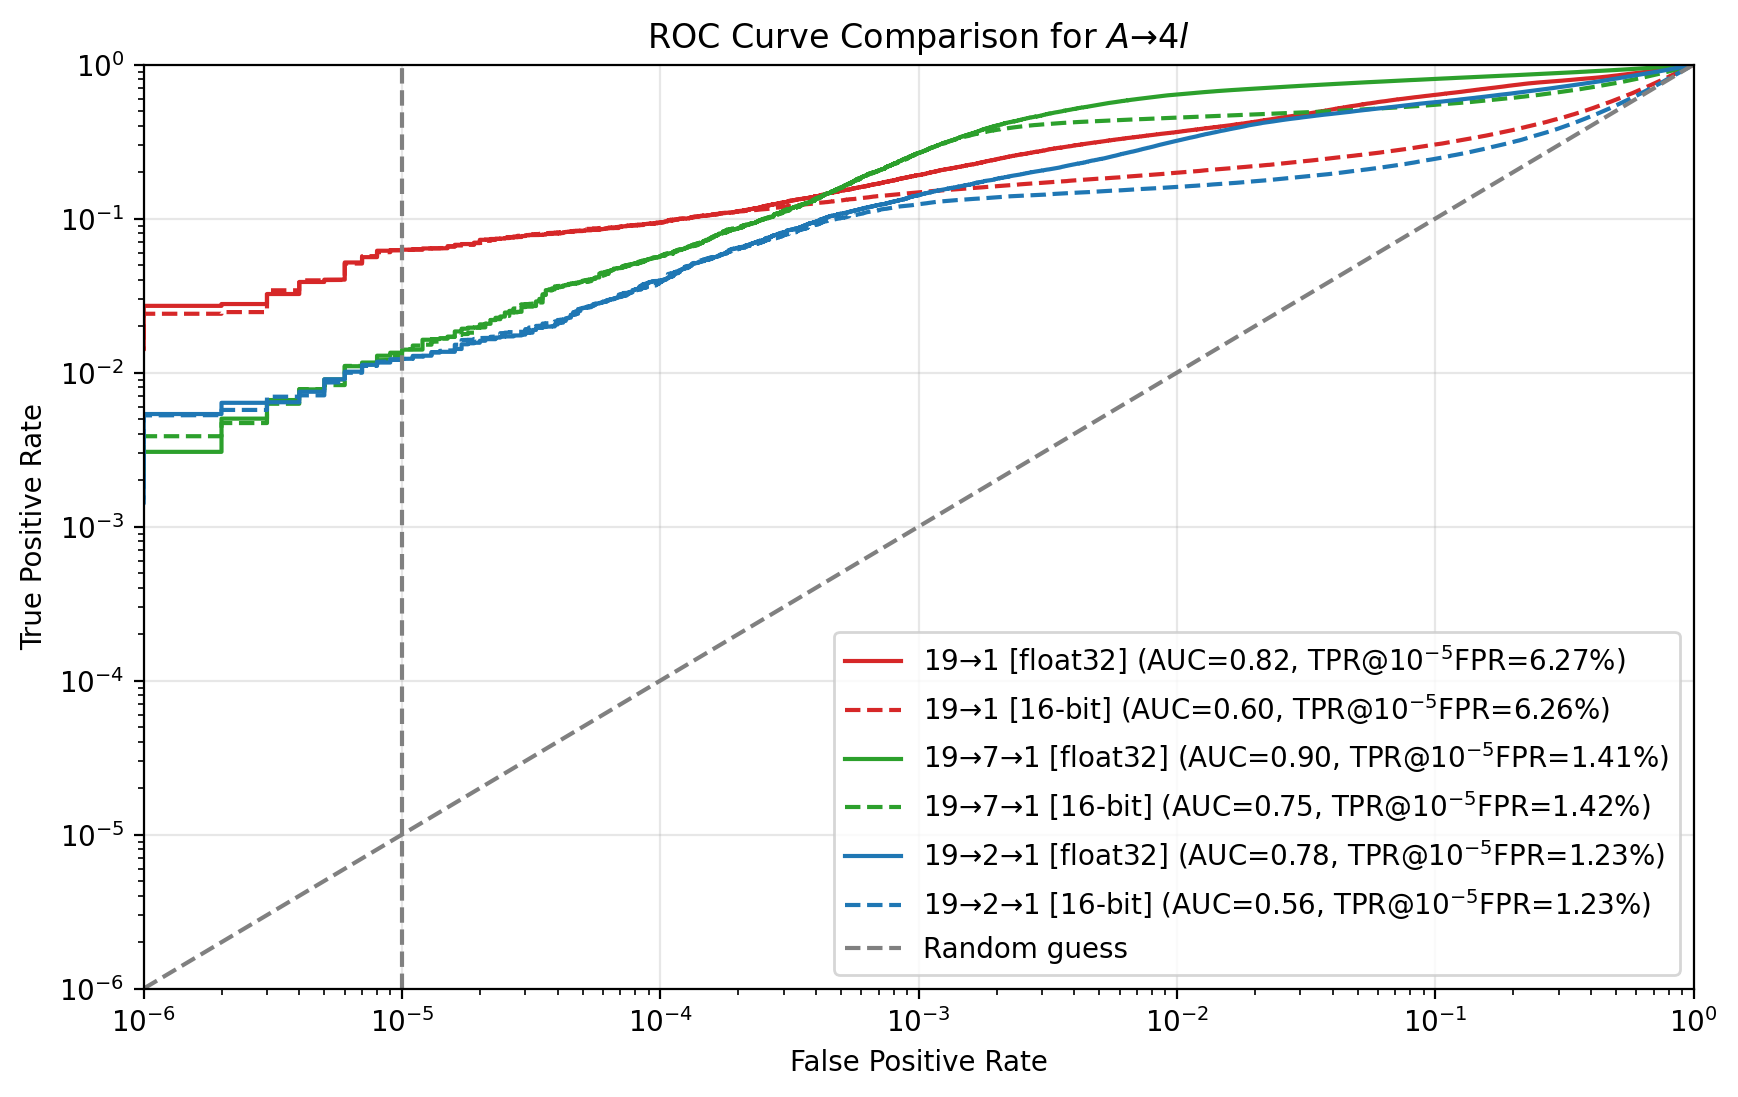

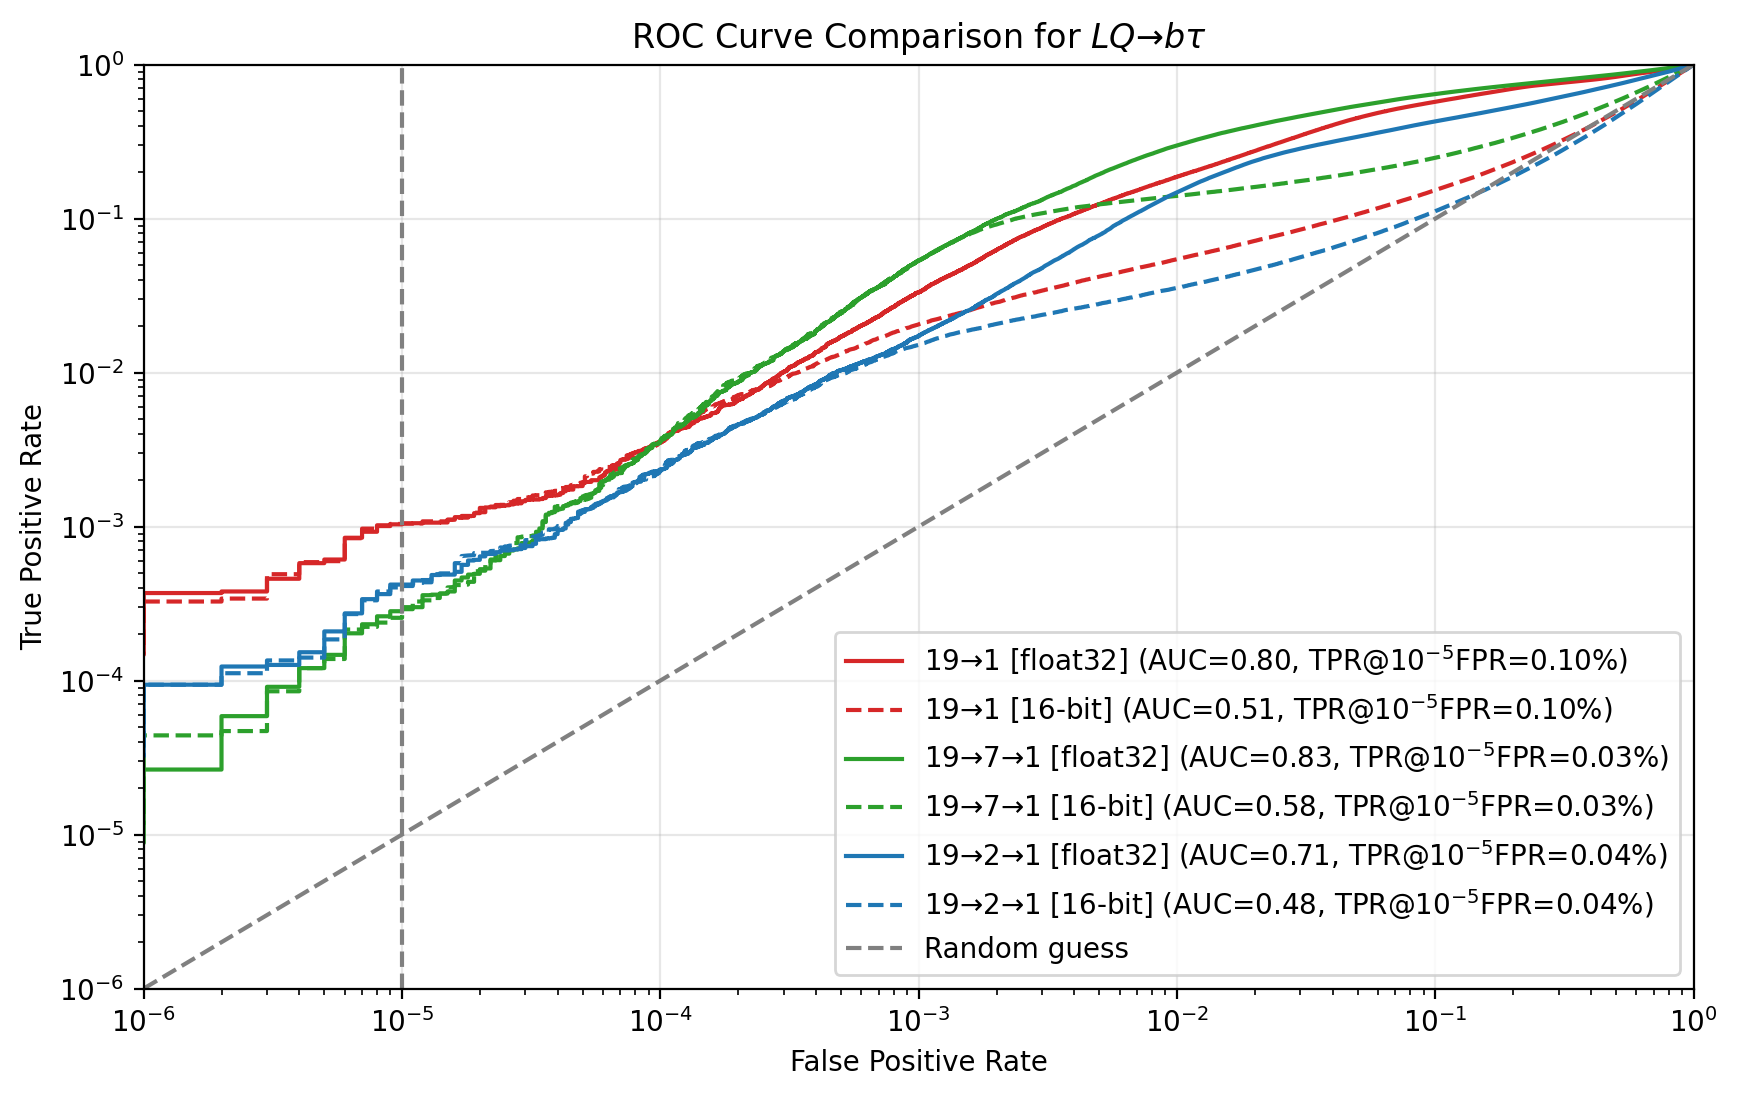

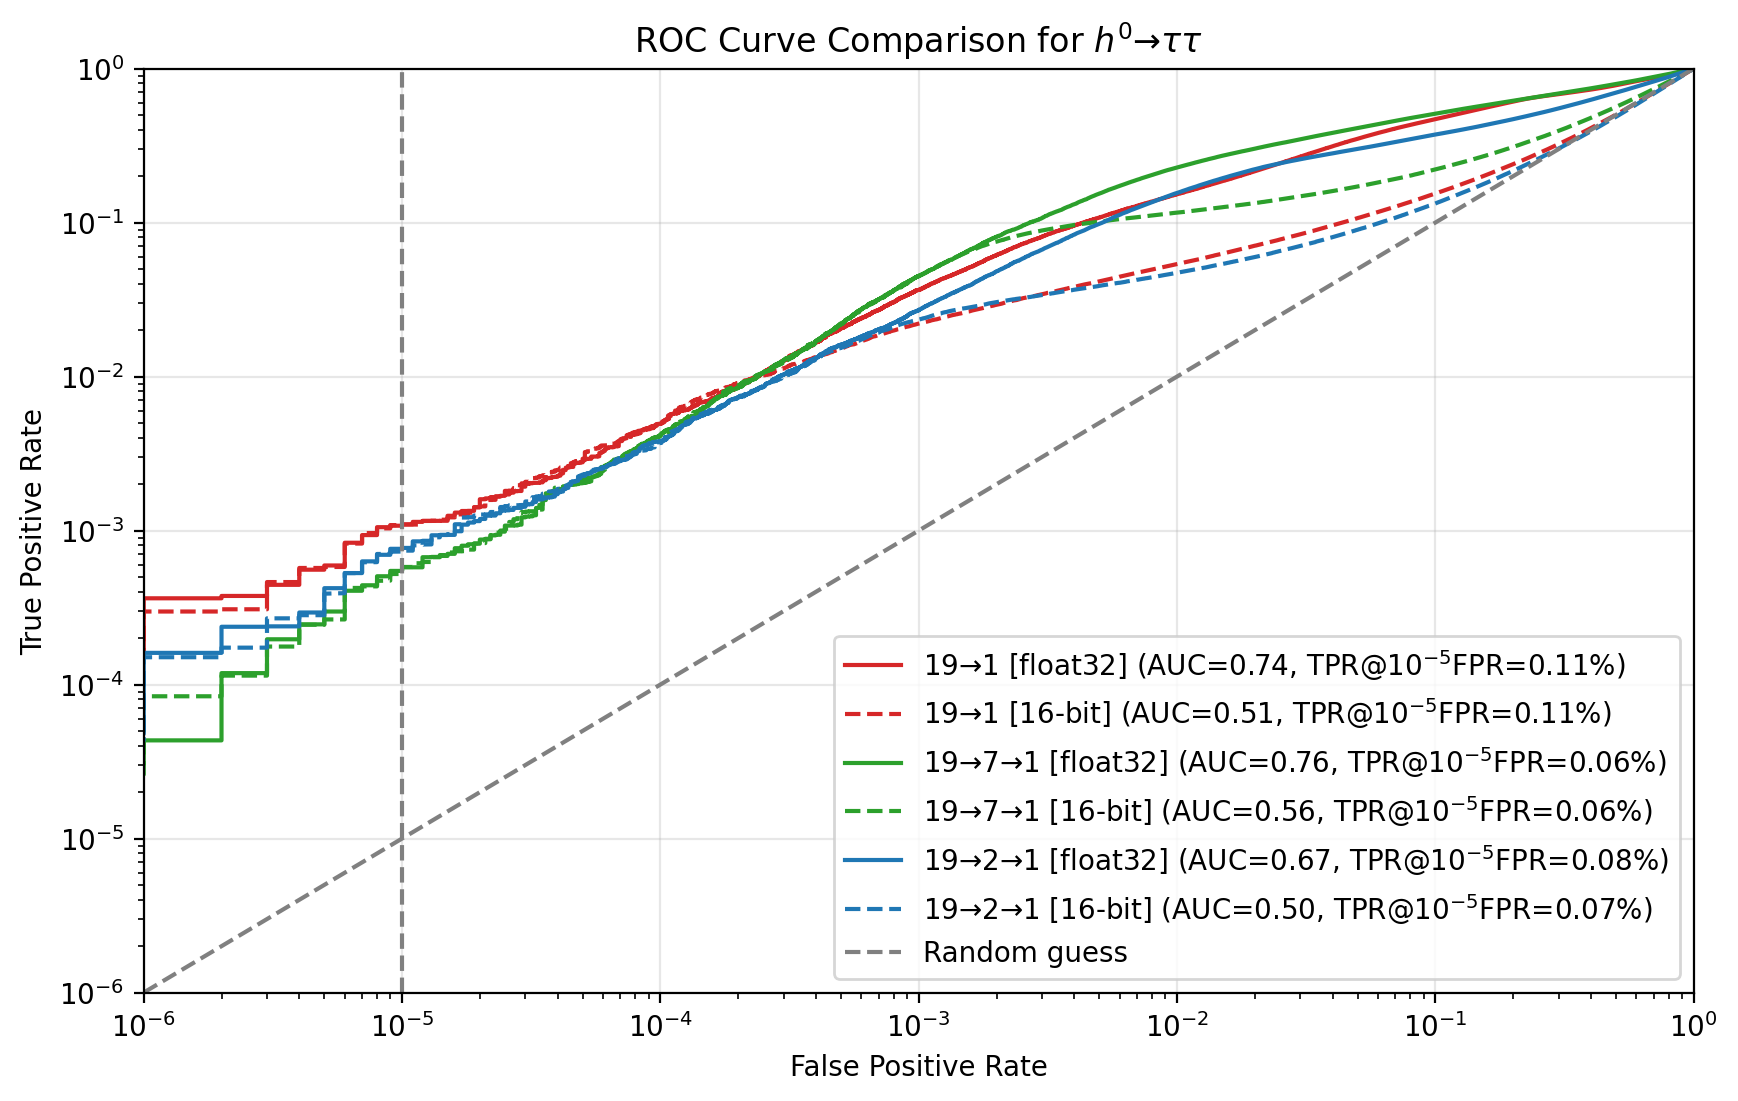

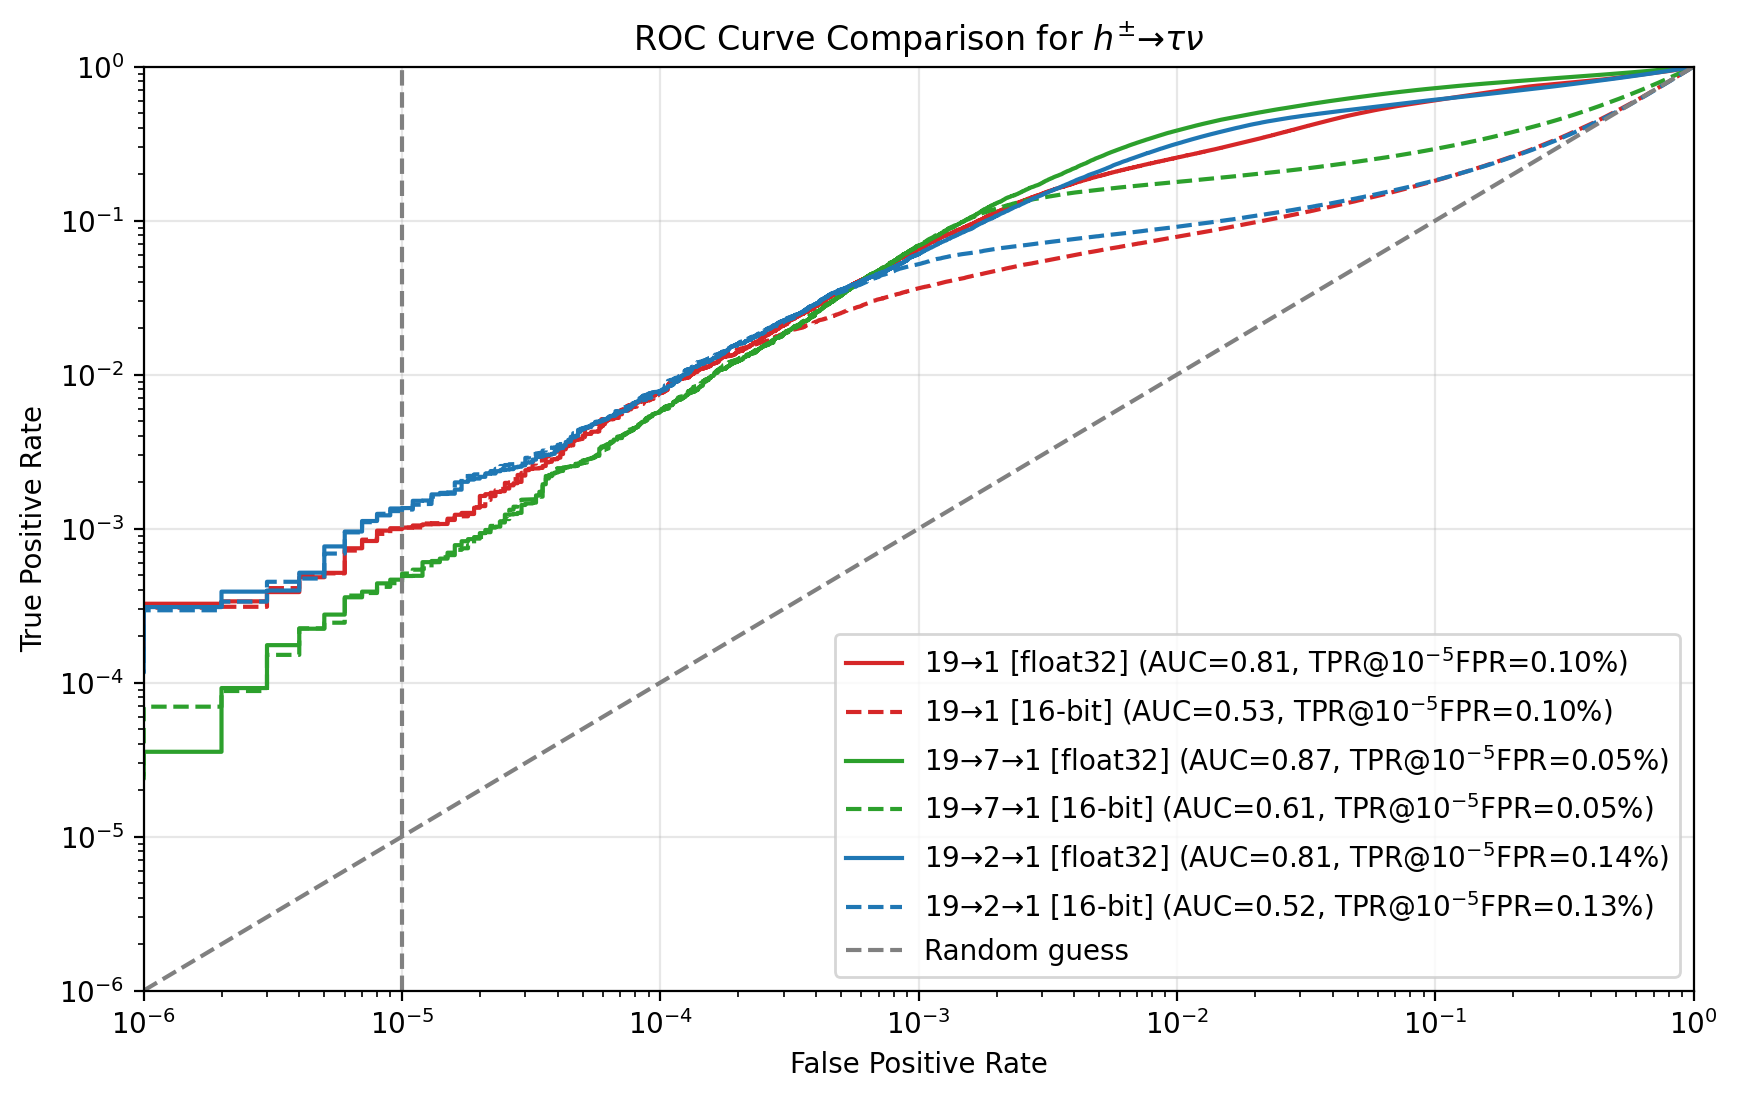

In [45]:
## Plot ROC curve per sample with different quantizations on the same plot
for sample in samples:
    plt.figure(figsize=(10, 6), dpi=200)
    if sample == "bkg":
        continue
    for model in models:
        for quant in quantizations:
            plt.plot(roc_data["fpr"][model][quant][sample], roc_data["tpr"][model][quant][sample], color=model_colors[model], linestyle = quant_linestyles[quant], label=f"{legend_names[model]} [{legend_names[quant]}] (AUC={roc_data['auc'][model][quant][sample]:.2f}, TPR@$10^{'{'}-5{'}'}$FPR={roc_data['tpr_at_1e_5_fpr'][model][quant][sample]*100:.2f}%)")
    plt.axvline(1e-5, color="gray", linestyle="--")
    plt.plot([1e-6, 1.0], [1e-6, 1.0], linestyle="--", color="gray", label="Random guess")
    # Draw y = sqrt(x) line for reference
    x_ref = np.linspace(1e-6, 1, 100)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Comparison for {legend_names[sample]}")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-6, 1)
    plt.ylim(1e-6, 1)
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")
    plt.show()